## Phase 4B — Biomarker Survival Analysis (Kaplan–Meier)

**Objective:**  
Assess the prognostic value of selected biomarkers in the TCGA-OV cohort using Kaplan–Meier (KM) survival curves.  

**Rationale:**  
Kaplan–Meier analysis provides a visual and statistical comparison of survival distributions between biomarker-defined patient subgroups.  
Here, patients are stratified into **Amplified (AMP)** vs **Non-Amplified (Neutral/Deleted)** groups based on GISTIC copy number calls.

**Methods:**  
- **Endpoint:** Overall Survival (OS), measured in months.  
- **Event coding:** OS status is binary (1 = death, 0 = censored).  
- **Grouping variable:** GISTIC-defined biomarker amplification status (AMP vs not AMP).  
- **Statistical test:** Log-rank test to evaluate survival curve differences.  
- **Plotting:**  
  - Median survival time and number at risk displayed.  
  - p-value from the log-rank test annotated on the plot.  
  - Separate KM plots are generated for each biomarker.

**Interpretation:**  
- A significant p-value (< 0.05) suggests the biomarker amplification is associated with differential survival in this cohort.  
- The direction of effect (better or worse survival in AMP group) is inferred from the separation of KM curves.


In [6]:
import pandas as pd
import numpy as np
from lifelines import CoxPHFitter
from statsmodels.stats.multitest import multipletests
import warnings
warnings.filterwarnings('ignore')

print("\n=== SL Target Survival + Biomarker Interaction Analysis ===\n")

# === Load SL pairs ===
print("Loading SL target–biomarker pairs...")
sl_pairs = pd.read_csv("../results/overlapping_amp_unified_hits_with_HGNC.csv")
sl_targets = sl_pairs[['TargetGene_Unified', 'TargetGene_Unified_HGNC',
                       'Biomarker_Unified', 'Biomarker_Unified_HGNC']].drop_duplicates()
print(f"Pairs loaded: {len(sl_pairs)} total, {len(sl_targets)} unique target–biomarker pairs")
print(f"Sample pairs:\n{sl_targets.head(5)}\n")

# === Load clinical data ===
print("Loading matched clinical data...")
clinical_df = pd.read_csv("../results/clinical_translation/clinical_matched.csv")
print(f"Clinical data: {clinical_df.shape}")
print(f"Sample patient IDs: {clinical_df['PATIENT_ID_CLEAN'].head(3).tolist()}")
clinical_df['AGE_CENTERED'] = clinical_df['AGE'] - clinical_df['AGE'].mean()
print("Age column centred (AGE_CENTERED)")

# === Load expression data ===
print("\nLoading TCGA-OV expression data...")
expr_df = pd.read_csv(
    "../database_files/cBioPortal/ov_tcga_pan_can_atlas_2018/data_mrna_seq_v2_rsem.txt",
    sep='\t'
)
expr_df = expr_df.set_index('Entrez_Gene_Id')
if 'Hugo_Symbol' in expr_df.columns:
    expr_df = expr_df.drop('Hugo_Symbol', axis=1)
expr_df.columns = [col.replace('-01', '').replace('-', '_') for col in expr_df.columns]
expr_df_log = np.log2(expr_df + 1)
print(f"Expression matrix: {expr_df_log.shape[0]} genes × {expr_df_log.shape[1]} samples")
print(f"Sample expression columns: {expr_df_log.columns[:3].tolist()}")

# === Load biomarker amplification calls ===
print("\nLoading biomarker amplification calls (binary GISTIC=2)...")
amp_df = pd.read_csv("../results/clinical_translation/biomarker_amplifications_matched.csv", index_col=0)
amp_df.columns = [c.replace('-', '_') for c in amp_df.columns]
amp_df.index = amp_df.index.astype(str)
print(f"Amplification matrix: {amp_df.shape[0]} biomarkers × {amp_df.shape[1]} samples")
print(f"Sample amp columns: {amp_df.columns[:3].tolist()}")

# === Prepare results containers ===
main_results = []
interaction_results = []

# === Loop through SL targets ===
print("\nProcessing target–biomarker pairs...")
for idx, row in sl_targets.iterrows():
    target_id = int(row['TargetGene_Unified'])
    target_symbol = row['TargetGene_Unified_HGNC']
    biomarker_id = str(row['Biomarker_Unified'])
    biomarker_symbol = row['Biomarker_Unified_HGNC']

    if str(target_id) not in expr_df_log.index.astype(str) or biomarker_id not in amp_df.index:
        print(f"  Skipped {target_symbol}–{biomarker_symbol}: missing in expression or amp matrix")
        continue

    expr_series = expr_df_log.loc[target_id]
    biomarker_series = amp_df.loc[biomarker_id]

    data = clinical_df[['PATIENT_ID_CLEAN', 'OS_MONTHS', 'OS_STATUS_BINARY', 'AGE_CENTERED']].copy()
    data['zExpr'] = data['PATIENT_ID_CLEAN'].map(expr_series)
    data['BIOMARKER_AMP'] = data['PATIENT_ID_CLEAN'].map(biomarker_series)

    if data['zExpr'].notna().sum() > 1:
        data['zExpr'] = (data['zExpr'] - data['zExpr'].mean()) / data['zExpr'].std(ddof=0)

    # --- Main effects ---
    main_cols = ['OS_MONTHS', 'OS_STATUS_BINARY', 'zExpr', 'AGE_CENTERED']
    data_main = data.dropna(subset=main_cols)
    if len(data_main) >= 30:
        try:
            cph_main = CoxPHFitter()
            cph_main.fit(data_main[main_cols], duration_col='OS_MONTHS', event_col='OS_STATUS_BINARY')
            hr = np.exp(cph_main.params_['zExpr'])
            ci = cph_main.confidence_intervals_.loc['zExpr'].apply(np.exp)
            pval = cph_main.summary.loc['zExpr', 'p']
            main_results.append({
                'TargetGene_ID': target_id,
                'TargetGene_HGNC': target_symbol,
                'Biomarker_HGNC': biomarker_symbol,
                'N_patients': len(data_main),
                'HR': hr, 'CI_lower': ci[0], 'CI_upper': ci[1], 'pval': pval
            })
            print(f"  Main model OK: {target_symbol} (n={len(data_main)}) HR={hr:.2f}, p={pval:.3g}")
        except Exception as e:
            print(f"  Main model skipped for {target_symbol}: {e}")

    # --- Interaction ---
    data['Expr_x_Biomarker'] = data['zExpr'] * data['BIOMARKER_AMP']
    int_cols = ['OS_MONTHS', 'OS_STATUS_BINARY', 'zExpr', 'BIOMARKER_AMP', 'Expr_x_Biomarker', 'AGE_CENTERED']
    data_int = data.dropna(subset=int_cols)
    if len(data_int) >= 30 and data_int['BIOMARKER_AMP'].nunique() >= 2:
        try:
            cph_int = CoxPHFitter()
            cph_int.fit(data_int[int_cols], duration_col='OS_MONTHS', event_col='OS_STATUS_BINARY')
            hr_int = np.exp(cph_int.params_['Expr_x_Biomarker'])
            ci_int = cph_int.confidence_intervals_.loc['Expr_x_Biomarker'].apply(np.exp)
            pval_int = cph_int.summary.loc['Expr_x_Biomarker', 'p']
            interaction_results.append({
                'TargetGene_ID': target_id,
                'TargetGene_HGNC': target_symbol,
                'Biomarker_HGNC': biomarker_symbol,
                'N_patients': len(data_int),
                'HR_interaction': hr_int, 'CI_lower_interaction': ci_int[0],
                'CI_upper_interaction': ci_int[1], 'pval_interaction': pval_int
            })
            print(f"    Interaction model OK: {target_symbol}×{biomarker_symbol} HR_int={hr_int:.2f}, p={pval_int:.3g}")
        except Exception as e:
            print(f"    Interaction model skipped for {target_symbol}: {e}")

# === Save results ===
main_df = pd.DataFrame(main_results)
if not main_df.empty:
    main_df['FDR'] = multipletests(main_df['pval'], method='fdr_bh')[1]
    main_df = main_df.sort_values('pval')
    main_df.to_csv("../results/clinical_translation/sl_target_survival_continuous.csv", index=False)
    print(f"\nSaved main effects: {main_df.shape[0]} genes → sl_target_survival_continuous.csv")

interaction_df = pd.DataFrame(interaction_results)
if not interaction_df.empty:
    interaction_df['FDR_interaction'] = multipletests(interaction_df['pval_interaction'], method='fdr_bh')[1]
    interaction_df = interaction_df.sort_values('pval_interaction')
    interaction_df.to_csv("../results/clinical_translation/sl_target_survival_interactions.csv", index=False)
    print(f"Saved interaction effects: {interaction_df.shape[0]} genes → sl_target_survival_interactions.csv")

print("\n=== Analysis complete ===")



=== SL Target Survival + Biomarker Interaction Analysis ===

Loading SL target–biomarker pairs...
Pairs loaded: 115 total, 115 unique target–biomarker pairs
Sample pairs:
   TargetGene_Unified TargetGene_Unified_HGNC  Biomarker_Unified  \
0              151648                    SGO1                208   
1              284459                  ZNF875                208   
2                4605                   MYBL2               5291   
3           102157402                     AK6                444   
4           102157402                     AK6                528   

  Biomarker_Unified_HGNC  
0                   AKT2  
1                   AKT2  
2                 PIK3CB  
3                   ASPH  
4               ATP6V1C1  

Loading matched clinical data...
Clinical data: (558, 43)
Sample patient IDs: ['TCGA_04_1331', 'TCGA_04_1332', 'TCGA_04_1335']
Age column centred (AGE_CENTERED)

Loading TCGA-OV expression data...
Expression matrix: 20531 genes × 300 samples
Sample express

## Plot Rationale

* **Volcano Plot (Main Effects)**

  * **Purpose:** Visualise the relationship between effect size (HR) and statistical significance (p-value) for all SL target genes in the continuous survival model.
  * **Why:** Quickly identifies targets with the strongest nominal associations, regardless of direction. Labels top 10 by FDR (or p if all FDR > 0.05).
  * **Reviewer Value:** Shows the spread of results and that the analysis is unbiased — both protective (HR < 1) and risk (HR > 1) effects are visible.

### Volcano Plot

4 [-0.25612977 -0.79175794]
5 [-0.64082937 -0.76174988]
6 [0.26609297 0.67279675]
7 [0.25892741 0.49328083]
8 [ 0.7517247 -0.110607 ]
1 [ 0.64387117 -0.78260717]
2 [0.09263083 0.79518213]


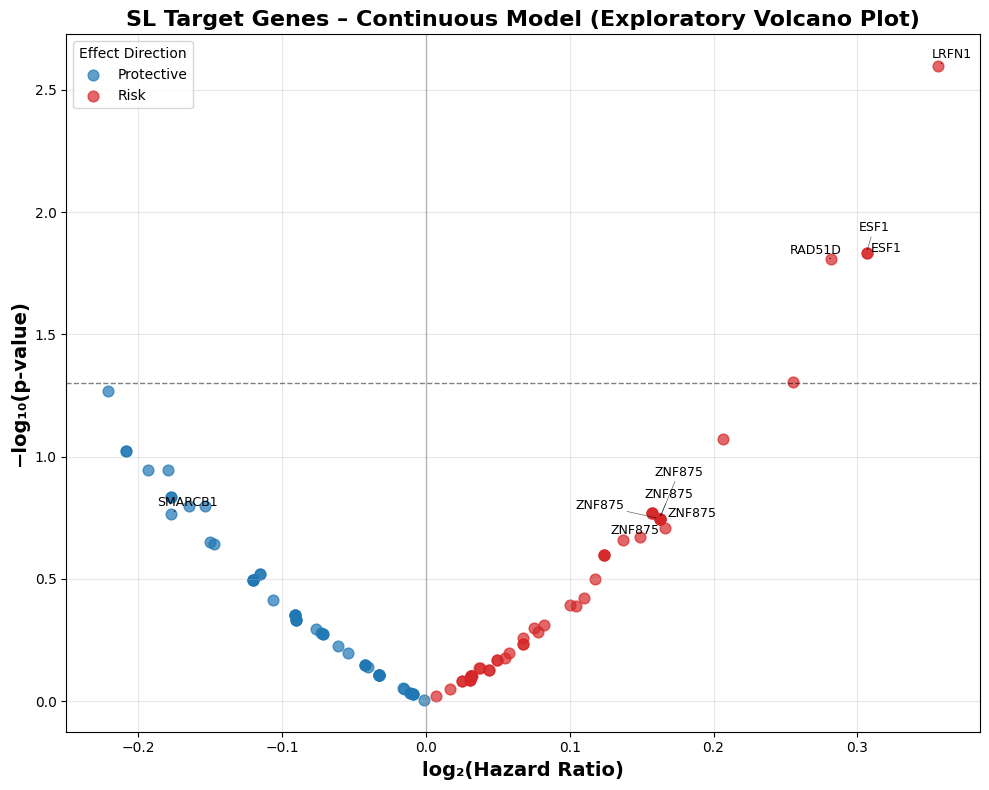

Volcano plot saved:
 - ../figures/volcano_sl_targets_main_effects.png
 - ../figures/volcano_sl_targets_main_effects.pdf


In [10]:
import pandas as pd

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from adjustText import adjust_text

# === Load data ===
df = pd.read_csv("../results/clinical_translation/sl_target_survival_continuous.csv")

# Log-transformed values for plotting
df['log2_HR'] = np.log2(df['HR'])
df['neg_log10_p'] = -np.log10(df['pval'])

# Choose ranking metric for labeling
rank_col = 'FDR'  # can change to 'pval' if you want
df_ranked = df.sort_values(rank_col).reset_index(drop=True)

# Colour map: protective vs risk
df['effect_dir'] = np.where(df['HR'] < 1, 'Protective', 'Risk')
colour_map = {'Protective': '#1f77b4', 'Risk': '#d62728'}

# === Plot ===
plt.figure(figsize=(10, 8))
for effect, subset in df.groupby('effect_dir'):
    plt.scatter(subset['log2_HR'], subset['neg_log10_p'],
                c=colour_map[effect], alpha=0.7, s=60, label=effect)

# Reference lines
plt.axhline(-np.log10(0.05), color='black', linestyle='--', lw=1, alpha=0.5)
plt.axvline(0, color='grey', linestyle='-', lw=1, alpha=0.5)

# Label top 10 by chosen ranking column
texts = []
top_hits = df_ranked.head(10)
for _, row in top_hits.iterrows():
    texts.append(
        plt.text(row['log2_HR'], row['neg_log10_p'], row['TargetGene_HGNC'],
                 fontsize=9, ha='center', va='bottom')
    )

# Adjust label positions
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='black', lw=0.5, alpha=0.6))

# Axis labels and title
plt.xlabel('log₂(Hazard Ratio)', fontsize=14, fontweight='bold')
plt.ylabel('−log₁₀(p-value)', fontsize=14, fontweight='bold')
plt.title('SL Target Genes – Continuous Model (Exploratory Volcano Plot)', fontsize=16, fontweight='bold')

# Legend and grid
plt.legend(title='Effect Direction')
plt.grid(True, alpha=0.3)

# Save
plt.tight_layout()
plt.savefig("../figures/volcano_sl_targets_main_effects.png", dpi=300)
plt.savefig("../figures/volcano_sl_targets_main_effects.pdf")
plt.show()

print("Volcano plot saved:")
print(" - ../figures/volcano_sl_targets_main_effects.png")
print(" - ../figures/volcano_sl_targets_main_effects.pdf")


4 [0.81773659 0.61664744]
9 [-0.64286181  0.44242139]


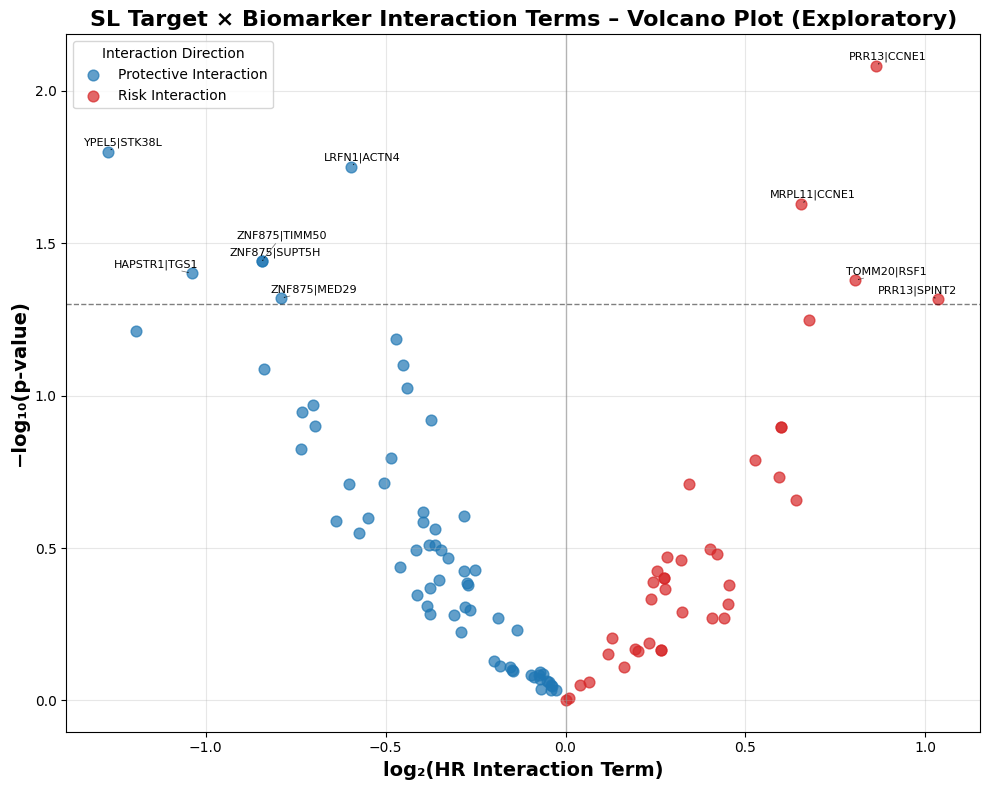

Volcano plot saved:
 - ../figures/volcano_sl_targets_interactions.png
 - ../figures/volcano_sl_targets_interactions.pdf


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from adjustText import adjust_text

# === Load data ===
df_int = pd.read_csv("../results/clinical_translation/sl_target_survival_interactions.csv")

# Log-transformed values for plotting
df_int['log2_HR_interaction'] = np.log2(df_int['HR_interaction'])
df_int['neg_log10_p'] = -np.log10(df_int['pval_interaction'])

# Choose ranking metric for labeling
rank_col = 'FDR_interaction'  # can change to 'pval_interaction' if preferred
df_ranked = df_int.sort_values(rank_col).reset_index(drop=True)

# Colour map: interaction HR < 1 vs > 1
df_int['effect_dir'] = np.where(df_int['HR_interaction'] < 1, 'Protective Interaction', 'Risk Interaction')
colour_map = {'Protective Interaction': '#1f77b4', 'Risk Interaction': '#d62728'}

# === Plot ===
plt.figure(figsize=(10, 8))
for effect, subset in df_int.groupby('effect_dir'):
    plt.scatter(subset['log2_HR_interaction'], subset['neg_log10_p'],
                c=colour_map[effect], alpha=0.7, s=60, label=effect)

# Reference lines
plt.axhline(-np.log10(0.05), color='black', linestyle='--', lw=1, alpha=0.5)
plt.axvline(0, color='grey', linestyle='-', lw=1, alpha=0.5)

# Label top 10 by chosen ranking column
texts = []
top_hits = df_ranked.head(10)
for _, row in top_hits.iterrows():
    label = f"{row['TargetGene_HGNC']}|{row['Biomarker_HGNC']}"
    texts.append(
        plt.text(row['log2_HR_interaction'], row['neg_log10_p'], label,
                 fontsize=8, ha='center', va='bottom')
    )

# Adjust label positions
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='black', lw=0.5, alpha=0.6))

# Axis labels and title
plt.xlabel('log₂(HR Interaction Term)', fontsize=14, fontweight='bold')
plt.ylabel('−log₁₀(p-value)', fontsize=14, fontweight='bold')
plt.title('SL Target × Biomarker Interaction Terms – Volcano Plot (Exploratory)', fontsize=16, fontweight='bold')

# Legend and grid
plt.legend(title='Interaction Direction')
plt.grid(True, alpha=0.3)

# Save
plt.tight_layout()
plt.savefig("../figures/volcano_sl_targets_interactions.png", dpi=300)
plt.savefig("../figures/volcano_sl_targets_interactions.pdf")
plt.show()

print("Volcano plot saved:")
print(" - ../figures/volcano_sl_targets_interactions.png")
print(" - ../figures/volcano_sl_targets_interactions.pdf")


## Prioritising SL Targets for Precision Oncology

**Goal:**  
Identify synthetic lethality (SL) target genes that are strong candidates for biomarker-guided cancer therapy.  
We focus on targets where inhibition is most likely to improve patient outcomes, especially in the biomarker-positive subgroup.

**Rationale:**
- **Continuous model (main effects)** — tests whether high target gene expression is associated with survival across all patients.  
  - **HR > 1 (risk)**: High expression → worse survival → candidate oncogenic dependency.
- **Interaction model** — tests whether the expression–survival relationship changes in biomarker-amplified vs biomarker-neutral patients.  
  - **HR_interaction > 1**: The harmful effect of high expression is **stronger** in the biomarker-positive subgroup.

**Why this matters:**  
This combination (HR > 1 in continuous, HR_interaction > 1 in interaction) is the ideal pattern for a **precision oncology** approach:
- The target is generally harmful (oncogenic dependency) in the tumour population.
- The effect is magnified in biomarker-positive patients → supports a biomarker-stratified therapy strategy.
- Aligns with the therapeutic goal: inhibit the target to selectively benefit the biomarker-positive subgroup.

**What we will do:**  
- Load main and interaction results.  
- Filter for **HR > 1** (continuous) **and** **HR_interaction > 1** (interaction).  
- Keep nominally interesting hits (p < 0.05 in either model) for further biological evaluation and plotting.


In [13]:
import pandas as pd

# Load results
main_df = pd.read_csv("../results/clinical_translation/sl_target_survival_continuous.csv")
int_df = pd.read_csv("../results/clinical_translation/sl_target_survival_interactions.csv")

# Merge on TargetGene_ID to align results
merged = pd.merge(
    main_df,
    int_df,
    on="TargetGene_ID",
    suffixes=("_main", "_int")
)

# Filter for desired pattern:
# HR > 1 in continuous AND HR_interaction > 1 in interaction
priority = merged[
    (merged['HR'] > 1) &
    (merged['HR_interaction'] > 1)
]

# Optional: keep only nominally interesting hits
priority_nominal = priority[
    (priority['pval'] < 0.05) | (priority['pval_interaction'] < 0.05)
]

# Save results
priority_nominal.to_csv("../results/clinical_translation/priority_hits_hr_gt1_both.csv", index=False)

print(f"Total priority hits (any p): {priority.shape[0]}")
print(f"Priority hits with nominal significance: {priority_nominal.shape[0]}")
print("Saved to ../results/clinical_translation/priority_hits_hr_gt1_both.csv")

# Show top hits
priority_nominal.sort_values(['pval', 'pval_interaction']).head(10)

Total priority hits (any p): 24
Priority hits with nominal significance: 4
Saved to ../results/clinical_translation/priority_hits_hr_gt1_both.csv


,TargetGene_ID,TargetGene_HGNC_main,Biomarker_HGNC_main,N_patients_main,HR,CI_lower,CI_upper,pval,FDR,TargetGene_HGNC_int,Biomarker_HGNC_int,N_patients_int,HR_interaction,CI_lower_interaction,CI_upper_interaction,pval_interaction,FDR_interaction
1,51575,ESF1,MFSD3,275,1.236609,1.042657,1.466639,0.014693,0.400952,ESF1,MFSD3,275,1.208955,0.779054,1.876086,0.397354,0.752694
2,51575,ESF1,MFSD3,275,1.236609,1.042657,1.466639,0.014693,0.400952,ESF1,LRRC14,275,1.208955,0.779054,1.876086,0.397354,0.752694
3,51575,ESF1,LRRC14,275,1.236609,1.042657,1.466639,0.014693,0.400952,ESF1,MFSD3,275,1.208955,0.779054,1.876086,0.397354,0.752694
4,51575,ESF1,LRRC14,275,1.236609,1.042657,1.466639,0.014693,0.400952,ESF1,LRRC14,275,1.208955,0.779054,1.876086,0.397354,0.752694


## SL Targets Showing Reversal Pattern in Biomarker-Amplified Patients

**Goal:**  
Identify target–biomarker pairs where the survival association **reverses** in the biomarker-positive subgroup.  
These are important to flag as *avoid* or *caution* cases for biomarker-stratified therapy.

**Definition of reversal pattern:**
- **Continuous model:** HR > 1 → Across all patients, high target expression is associated with worse survival (risk).
- **Interaction model:** HR_interaction < 1 → In biomarker-amplified patients, the harmful effect is **reduced** or even **protective**.

**Why this matters:**  
- For precision oncology, we want the biomarker-positive group to show *stronger* dependency (HR_interaction > 1).  
- A reversal pattern suggests the target may **not** be a good biomarker-guided vulnerability:  
  - The biomarker-positive tumours do not show the same or stronger risk association.
  - In some cases, the target’s role could be different in the biomarker context (bypass pathways, context-dependent biology).
- Including these as biomarker-stratified therapy candidates could risk ineffective or counterproductive treatment.

**Use in interpretation:**  
- These hits should be excluded from the primary biomarker-target short list.
- They can be mentioned in the discussion as examples of context-dependent effects, highlighting the need for biomarker-specific validation.


In [14]:
import pandas as pd

# Load results
main_df = pd.read_csv("../results/clinical_translation/sl_target_survival_continuous.csv")
int_df = pd.read_csv("../results/clinical_translation/sl_target_survival_interactions.csv")

# Merge on TargetGene_ID
merged = pd.merge(
    main_df,
    int_df,
    on="TargetGene_ID",
    suffixes=("_main", "_int")
)

# Filter for reversal pattern
reverse_pattern = merged[
    (merged['HR'] > 1) &
    (merged['HR_interaction'] < 1)
]

# Optional: keep nominally significant in either model
reverse_nominal = reverse_pattern[
    (reverse_pattern['pval'] < 0.05) | (reverse_pattern['pval_interaction'] < 0.05)
]

# Save
reverse_nominal.to_csv("../results/clinical_translation/reverse_pattern_hits.csv", index=False)

print(f"Reversal hits (any p): {reverse_pattern.shape[0]}")
print(f"Reversal hits with nominal significance: {reverse_nominal.shape[0]}")
print("Saved to ../results/clinical_translation/reverse_pattern_hits.csv")

# Show top
reverse_nominal.sort_values(['pval', 'pval_interaction']).head(10)


Reversal hits (any p): 106
Reversal hits with nominal significance: 20
Saved to ../results/clinical_translation/reverse_pattern_hits.csv


,TargetGene_ID,TargetGene_HGNC_main,Biomarker_HGNC_main,N_patients_main,HR,CI_lower,CI_upper,pval,FDR,TargetGene_HGNC_int,Biomarker_HGNC_int,N_patients_int,HR_interaction,CI_lower_interaction,CI_upper_interaction,pval_interaction,FDR_interaction
0,57622,LRFN1,ACTN4,275,1.280211,1.090588,1.502803,0.002526,0.260189,LRFN1,ACTN4,275,0.661040,0.469489,0.930743,0.017736,0.497426
5,5892,RAD51D,NDUFB9,275,1.215718,1.037751,1.424205,0.015571,0.400952,RAD51D,NDUFB9,275,0.964904,0.636919,1.461786,0.866131,0.940410
6,147965,FAM98C,RSF1,275,1.193655,1.000274,1.424422,0.049645,0.770297,FAM98C,RSF1,275,0.940549,0.519839,1.701745,0.839450,0.940410
31,284459,ZNF875,SUPT5H,275,1.119230,0.949493,1.319309,0.179487,0.770297,ZNF875,TIMM50,275,0.557070,0.322315,0.962806,0.036105,0.497426
32,284459,ZNF875,SUPT5H,275,1.119230,0.949493,1.319309,0.179487,0.770297,ZNF875,SUPT5H,275,0.557070,0.322315,0.962806,0.036105,0.497426
36,284459,ZNF875,MED29,275,1.119230,0.949493,1.319309,0.179487,0.770297,ZNF875,TIMM50,275,0.557070,0.322315,0.962806,0.036105,0.497426
37,284459,ZNF875,MED29,275,1.119230,0.949493,1.319309,0.179487,0.770297,ZNF875,SUPT5H,275,0.557070,0.322315,0.962806,0.036105,0.497426
41,284459,ZNF875,TIMM50,275,1.119230,0.949493,1.319309,0.179487,0.770297,ZNF875,TIMM50,275,0.557070,0.322315,0.962806,0.036105,0.497426
42,284459,ZNF875,TIMM50,275,1.119230,0.949493,1.319309,0.179487,0.770297,ZNF875,SUPT5H,275,0.557070,0.322315,0.962806,0.036105,0.497426
46,284459,ZNF875,AKT2,275,1.119230,0.949493,1.319309,0.179487,0.770297,ZNF875,TIMM50,275,0.557070,0.322315,0.962806,0.036105,0.497426


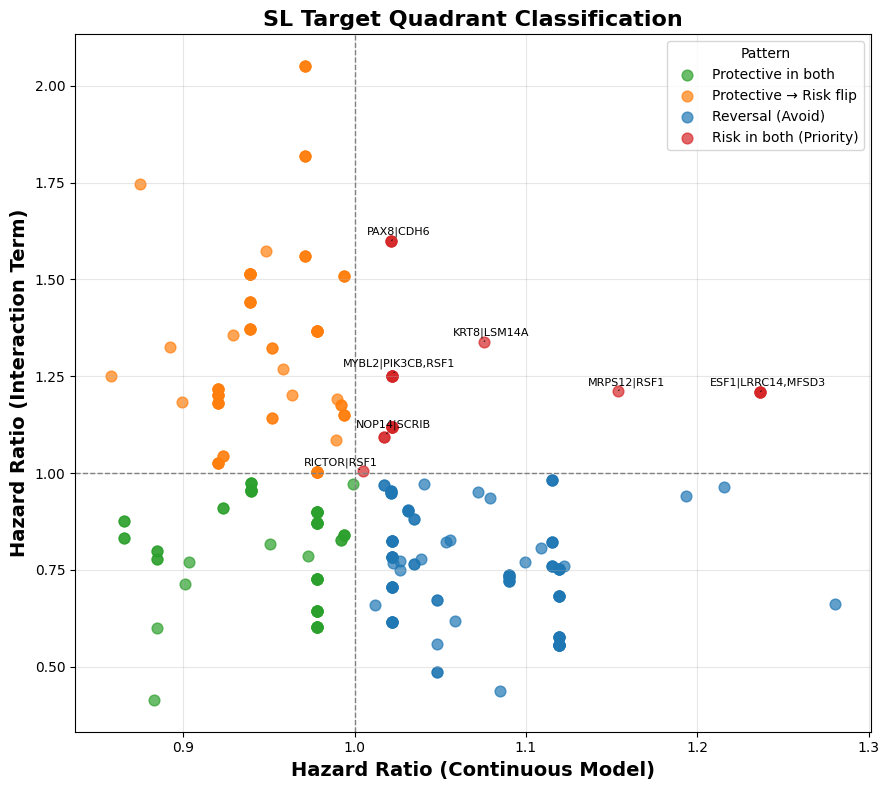

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Load results
main_df = pd.read_csv("../results/clinical_translation/sl_target_survival_continuous.csv")
int_df = pd.read_csv("../results/clinical_translation/sl_target_survival_interactions.csv")

# Merge
merged = pd.merge(
    main_df,
    int_df,
    on="TargetGene_ID",
    suffixes=("_main", "_int")
)

# Classify quadrants
def classify_quadrant(row):
    if row['HR'] > 1 and row['HR_interaction'] > 1:
        return "Risk in both (Priority)"
    elif row['HR'] > 1 and row['HR_interaction'] < 1:
        return "Reversal (Avoid)"
    elif row['HR'] < 1 and row['HR_interaction'] > 1:
        return "Protective → Risk flip"
    else:
        return "Protective in both"

merged['Quadrant'] = merged.apply(classify_quadrant, axis=1)

# Colour map
colour_map = {
    "Risk in both (Priority)": "#d62728",        
    "Reversal (Avoid)": "#1f77b4",               
    "Protective → Risk flip": "#ff7f0e",         
    "Protective in both": "#2ca02c"              
}

# Aggregate biomarker names for each target in the priority quadrant
priority_labels = (
    merged[merged['Quadrant'] == "Risk in both (Priority)"]
    .groupby('TargetGene_HGNC_main')['Biomarker_HGNC_int']
    .apply(lambda x: ",".join(sorted(set(x))))
    .reset_index()
)

# Merge aggregated labels back with a single HR/HR_interaction per target
priority_plot_data = (
    merged[merged['Quadrant'] == "Risk in both (Priority)"]
    .drop_duplicates(subset=['TargetGene_HGNC_main'])
    [['TargetGene_HGNC_main', 'HR', 'HR_interaction']]
    .merge(priority_labels, on='TargetGene_HGNC_main')
)

# Plot
plt.figure(figsize=(9, 8))
texts = []
for group, subset in merged.groupby('Quadrant'):
    plt.scatter(subset['HR'], subset['HR_interaction'],
                c=colour_map[group], alpha=0.7, s=60, label=group)

# Label only once per target in the priority quadrant
for _, row in priority_plot_data.iterrows():
    label = f"{row['TargetGene_HGNC_main']}|{row['Biomarker_HGNC_int']}"
    texts.append(
        plt.text(row['HR'], row['HR_interaction'], label,
                 fontsize=8, ha='center', va='bottom')
    )

adjust_text(texts, arrowprops=dict(arrowstyle='->', color='black', lw=0.5, alpha=0.6))

# Reference lines
plt.axhline(1, color='grey', linestyle='--', lw=1)
plt.axvline(1, color='grey', linestyle='--', lw=1)

# Labels and title
plt.xlabel("Hazard Ratio (Continuous Model)", fontsize=14, fontweight='bold')
plt.ylabel("Hazard Ratio (Interaction Term)", fontsize=14, fontweight='bold')
plt.title("SL Target Quadrant Classification", fontsize=16, fontweight='bold')

# Legend
plt.legend(title="Pattern", loc='upper right')
plt.grid(alpha=0.3)
plt.tight_layout()

# Save
plt.savefig("../figures/sl_target_hr_quadrants_labels_combined.png", dpi=300)
plt.savefig("../figures/sl_target_hr_quadrants_labels_combined.pdf")
plt.show()

### Drug Sensitivity Correlation

In [42]:
import os
import json
import pandas as pd
import requests
from typing import Optional

# --- Load HGNC mapping ---
def load_hgnc_map(filepath: str) -> dict:
    df = pd.read_csv(filepath, sep="\t", dtype=str)
    return dict(zip(df["symbol"], df["ensembl_gene_id"]))

hgnc_map_path = "../database_files/gene_with_protein_product.txt"
hgnc_map = load_hgnc_map(hgnc_map_path)

# --- Open Targets fetch function ---
def fetch_opentargets_info(symbol: str, hgnc_map: dict) -> dict:
    ensembl_id = hgnc_map.get(symbol)
    if not ensembl_id:
        return {"ERROR": f"No Ensembl ID for {symbol}"}
    
    query = """
    query target($ensemblId: String!) {
      target(ensemblId: $ensemblId) {
        id
        approvedSymbol
        tractability {
          label
          modality
          value
        }
        knownDrugs {
          count
          rows {
            phase
            status
            drug {
              name
            }
            disease {
              name
            }
            mechanismOfAction
          }
        }
      }
    }
    """
    variables = {"ensemblId": ensembl_id}
    url = "https://api.platform.opentargets.org/api/v4/graphql"

    try:
        res = requests.post(url, json={"query": query, "variables": variables})
        res.raise_for_status()
        data = res.json()

        if "errors" in data:
            return {"ERROR": data["errors"]}

        target_data = data.get("data", {}).get("target")
        if not target_data:
            return {"ERROR": "No target data found"}

        tractability = target_data.get("tractability", [])
        known_drugs = target_data.get("knownDrugs", {})
        drugs = known_drugs.get("rows", [])

        sm_scores = [t for t in tractability if t.get("modality") == "SM"]
        tract_labels = {t.get("label", ""): t.get("value", False) for t in sm_scores}
        true_labels = {label for label, value in tract_labels.items() if value}

        high_conf_labels = {"Approved Drug"}
        mid_conf_labels = {"Advanced Clinical", "Phase 1 Clinical", "Clinical Precedence"}
        low_conf_labels = {"Structure with Ligand", "High-Quality Ligand", "High-Quality Pocket", "Druggable Family"}

        if true_labels & high_conf_labels:
            interpretation = "HIGH tractability (approved drug exists)"
        elif true_labels & mid_conf_labels:
            interpretation = "MODERATE tractability (clinical-stage target)"
        elif true_labels & low_conf_labels:
            interpretation = "LOW tractability (ligandable but no clinical-stage evidence)"
        else:
            interpretation = "LOW tractability (no tractability evidence)"

        return {
            "TRACTABILITY_SCORES": tract_labels,
            "TRACTABILITY_FLAGS": len(true_labels),
            "TRACTABILITY_INTERPRETATION": interpretation,
            "KNOWN_DRUGS": drugs
        }

    except Exception as e:
        return {"ERROR": str(e)}

# --- Load SL targets ---
sl_pairs_path = "../results/overlapping_amp_unified_hits_with_HGNC.csv"
pairs_df = pd.read_csv(sl_pairs_path)
sl_targets = sorted(set(pairs_df['TargetGene_Unified_HGNC']))

# --- Query Open Targets ---
results = []
for idx, gene in enumerate(sl_targets, start=1):
    print(f"[{idx}/{len(sl_targets)}] Fetching Open Targets data for: {gene}")
    info = fetch_opentargets_info(gene, hgnc_map)

    if "ERROR" in info:
        results.append({
            "Gene": gene,
            "Error": info["ERROR"],
            "Tractability_Flags": None,
            "Tractability_Interpretation": None,
            "Known_Drugs": None
        })
    else:
        drug_names = list({d['drug']['name'] for d in info["KNOWN_DRUGS"]}) if info["KNOWN_DRUGS"] else []
        results.append({
            "Gene": gene,
            "Error": None,
            "Tractability_Flags": info["TRACTABILITY_FLAGS"],
            "Tractability_Interpretation": info["TRACTABILITY_INTERPRETATION"],
            "Known_Drugs": "; ".join(drug_names) if drug_names else None
        })

# --- Save table ---
df_out = pd.DataFrame(results)
out_path = "../results/clinical_translation/sl_target_opentargets_drug_info.csv"
df_out.to_csv(out_path, index=False)
print(f"\nSaved Open Targets drug info → {out_path}")

[1/62] Fetching Open Targets data for: AK6
[2/62] Fetching Open Targets data for: APLP1
[3/62] Fetching Open Targets data for: CCDC174
[4/62] Fetching Open Targets data for: CCNE1
[5/62] Fetching Open Targets data for: CDK2
[6/62] Fetching Open Targets data for: CENPI
[7/62] Fetching Open Targets data for: COA7
[8/62] Fetching Open Targets data for: CUL1
[9/62] Fetching Open Targets data for: DDX39B
[10/62] Fetching Open Targets data for: DPRX
[11/62] Fetching Open Targets data for: ESF1
[12/62] Fetching Open Targets data for: FAM98C
[13/62] Fetching Open Targets data for: HAMP
[14/62] Fetching Open Targets data for: HAPSTR1
[15/62] Fetching Open Targets data for: HAUS2
[16/62] Fetching Open Targets data for: KDM2A
[17/62] Fetching Open Targets data for: KRT8
[18/62] Fetching Open Targets data for: LENG8
[19/62] Fetching Open Targets data for: LGALS4
[20/62] Fetching Open Targets data for: LIN54
[21/62] Fetching Open Targets data for: LRFN1
[22/62] Fetching Open Targets data for: MAEA


In [44]:
import os
import json
import pandas as pd
import requests
from typing import Optional

# --- Load HGNC mapping ---
def load_hgnc_map(filepath: str) -> dict:
    df = pd.read_csv(filepath, sep="\t", dtype=str)
    return dict(zip(df["symbol"], df["ensembl_gene_id"]))

hgnc_map_path = "../database_files/gene_with_protein_product.txt"
hgnc_map = load_hgnc_map(hgnc_map_path)

# --- Open Targets fetch function ---
def fetch_opentargets_info(symbol: str, hgnc_map: dict) -> dict:
    ensembl_id = hgnc_map.get(symbol)
    if not ensembl_id:
        return {"ERROR": f"No Ensembl ID for {symbol}"}
    
    query = """
    query target($ensemblId: String!) {
      target(ensemblId: $ensemblId) {
        id
        approvedSymbol
        tractability {
          label
          modality
          value
        }
        knownDrugs {
          count
          rows {
            phase
            status
            drug {
              name
            }
            disease {
              name
            }
            mechanismOfAction
          }
        }
      }
    }
    """
    variables = {"ensemblId": ensembl_id}
    url = "https://api.platform.opentargets.org/api/v4/graphql"

    try:
        res = requests.post(url, json={"query": query, "variables": variables})
        res.raise_for_status()
        data = res.json()

        if "errors" in data:
            return {"ERROR": data["errors"]}

        target_data = data.get("data", {}).get("target")
        if not target_data:
            return {"ERROR": "No target data found"}

        tractability = target_data.get("tractability", [])
        known_drugs = target_data.get("knownDrugs", {})
        drugs = known_drugs.get("rows", [])

        sm_scores = [t for t in tractability if t.get("modality") == "SM"]
        tract_labels = {t.get("label", ""): t.get("value", False) for t in sm_scores}
        true_labels = {label for label, value in tract_labels.items() if value}

        high_conf_labels = {"Approved Drug"}
        mid_conf_labels = {"Advanced Clinical", "Phase 1 Clinical", "Clinical Precedence"}
        low_conf_labels = {"Structure with Ligand", "High-Quality Ligand", "High-Quality Pocket", "Druggable Family"}

        if true_labels & high_conf_labels:
            interpretation = "HIGH tractability (approved drug exists)"
        elif true_labels & mid_conf_labels:
            interpretation = "MODERATE tractability (clinical-stage target)"
        elif true_labels & low_conf_labels:
            interpretation = "LOW tractability (ligandable but no clinical-stage evidence)"
        else:
            interpretation = "LOW tractability (no tractability evidence)"

        return {
            "TRACTABILITY_SCORES": tract_labels,
            "TRACTABILITY_FLAGS": len(true_labels),
            "TRACTABILITY_INTERPRETATION": interpretation,
            "KNOWN_DRUGS": drugs
        }

    except Exception as e:
        return {"ERROR": str(e)}

# --- Load SL target–biomarker pairs ---
sl_pairs_path = "../results/overlapping_amp_unified_hits_with_HGNC.csv"
pairs_df = pd.read_csv(sl_pairs_path)[['Biomarker_Unified_HGNC', 'TargetGene_Unified_HGNC']].drop_duplicates()

# --- Query Open Targets for each pair's target ---
results = []
for idx, row in pairs_df.iterrows():
    biomarker = row['Biomarker_Unified_HGNC']
    target = row['TargetGene_Unified_HGNC']
    print(f"[{idx+1}/{len(pairs_df)}] Fetching Open Targets data for pair: {biomarker} – {target}")
    
    info = fetch_opentargets_info(target, hgnc_map)

    if "ERROR" in info:
        results.append({
            "Biomarker": biomarker,
            "Target": target,
            "Error": info["ERROR"],
            "Tractability_Flags": None,
            "Tractability_Interpretation": None,
            "Known_Drugs": None
        })
    else:
        drug_names = list({d['drug']['name'] for d in info["KNOWN_DRUGS"]}) if info["KNOWN_DRUGS"] else []
        results.append({
            "Biomarker": biomarker,
            "Target": target,
            "Error": None,
            "Tractability_Flags": info["TRACTABILITY_FLAGS"],
            "Tractability_Interpretation": info["TRACTABILITY_INTERPRETATION"],
            "Known_Drugs": "; ".join(drug_names) if drug_names else None
        })

# --- Save output ---
out_path = "../results/clinical_translation/sl_pairs_opentargets_drug_info.csv"
df_out = pd.DataFrame(results)
df_out.to_csv(out_path, index=False)
print(f"\nSaved Open Targets drug info for SL pairs → {out_path}")

[1/115] Fetching Open Targets data for pair: AKT2 – SGO1
[2/115] Fetching Open Targets data for pair: AKT2 – ZNF875
[3/115] Fetching Open Targets data for pair: PIK3CB – MYBL2
[4/115] Fetching Open Targets data for pair: ASPH – AK6
[5/115] Fetching Open Targets data for pair: ATP6V1C1 – AK6
[6/115] Fetching Open Targets data for pair: BICD1 – SNAP23
[7/115] Fetching Open Targets data for pair: LRRC14 – ESF1
[8/115] Fetching Open Targets data for pair: CCDC91 – SNAP23
[9/115] Fetching Open Targets data for pair: CCNE1 – CCDC174
[10/115] Fetching Open Targets data for pair: CCNE1 – CCNE1
[11/115] Fetching Open Targets data for pair: CCNE1 – CDK2
[12/115] Fetching Open Targets data for pair: CCNE1 – HAMP
[13/115] Fetching Open Targets data for pair: CCNE1 – LENG8
[14/115] Fetching Open Targets data for pair: CCNE1 – MRPL11
[15/115] Fetching Open Targets data for pair: CCNE1 – MRPS14
[16/115] Fetching Open Targets data for pair: CCNE1 – MTERF3
[17/115] Fetching Open Targets data for pair: 

In [54]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr

# ======================
# Paths (edit if needed)
# ======================
pairs_path = "../results/overlapping_amp_unified_hits_with_HGNC.csv"
opentargets_path = "../results/clinical_translation/sl_pairs_opentargets_drug_info.csv"
gdsc_path = "../results/gdsc_hgsoc.csv"
crispr_path = "../results/crispr_hgsoc.csv"
cna_depmap_path = "../results/cna_depmap_hgsoc.csv"   # DepMap absolute copy number
hgnc_map_path = "../database_files/gene_with_protein_product.txt"

# ======================
# Parameters
# ======================
AMP_THRESHOLD = 6            # AMP+ if absolute CN >= 6
MIN_N_LINES = 3              # minimum overlapping lines for correlation

# Manual drug name mapping (Open Targets → GDSC)
drug_name_map = {
    "FLUDARABINE PHOSPHATE": "FLUDARABINE",
    "GEMCITABINE HYDROCHLORIDE": "GEMCITABINE",
    "GEMCITABINE": "GEMCITABINE",
    "CLOFARABINE": "CLOFARABINE",
    # Add others here if needed
}

# ======================
# Load core data
# ======================
pairs_df = pd.read_csv(pairs_path)[['Biomarker_Unified_HGNC', 'TargetGene_Unified_HGNC']].drop_duplicates()

drug_info_df = pd.read_csv(opentargets_path)[[
    'Biomarker', 'Target', 'Known_Drugs', 'Tractability_Flags', 'Tractability_Interpretation'
]]

gdsc_df = pd.read_csv(gdsc_path)[['ARXSPAN_ID', 'DRUG_NAME', 'AUC_PUBLISHED']]
gdsc_df['ARXSPAN_ID'] = gdsc_df['ARXSPAN_ID'].astype(str).str.replace('_', '-', regex=False).str.upper()
gdsc_df['DRUG_NAME_UP'] = gdsc_df['DRUG_NAME'].astype(str).str.upper()

# CRISPR dependency (rows = ACH-*, cols = Entrez IDs)
crispr_df = pd.read_csv(crispr_path, index_col=0)
crispr_df.index = crispr_df.index.astype(str).str.replace('_', '-', regex=False).str.upper()
crispr_df.columns = crispr_df.columns.astype(str)

# DepMap CNA absolute copy number
cna_df = pd.read_csv(cna_depmap_path, index_col=0)
cna_df.index = cna_df.index.astype(str).str.replace('_', '-', regex=False).str.upper()
cna_df.columns = cna_df.columns.astype(str)

# HGNC → Entrez mapping
hgnc_df = pd.read_csv(hgnc_map_path, sep="\t", dtype=str)
symbol_to_entrez = dict(zip(hgnc_df["symbol"], hgnc_df["entrez_id"]))

# ======================
# Filter to pairs whose targets have known drugs
# ======================
targets_with_drugs = set(drug_info_df.loc[drug_info_df['Known_Drugs'].notna(), 'Target'])
pairs_df = pairs_df[pairs_df['TargetGene_Unified_HGNC'].isin(targets_with_drugs)].reset_index(drop=True)
print(f"Filtered to {len(pairs_df)} pairs with known drugs")

# ======================
# Analysis
# ======================
results = []

for idx, row in pairs_df.iterrows():
    biomarker_sym = row['Biomarker_Unified_HGNC']
    target_sym = row['TargetGene_Unified_HGNC']
    print(f"\n[{idx+1}/{len(pairs_df)}] {biomarker_sym} – {target_sym}")

    # Map to Entrez
    biomarker_entrez = symbol_to_entrez.get(biomarker_sym)
    target_entrez = symbol_to_entrez.get(target_sym)

    if biomarker_entrez is None:
        print(f"  Skip: no Entrez for biomarker {biomarker_sym}")
        continue
    if target_entrez is None:
        print(f"  Skip: no Entrez for target {target_sym}")
        continue

    biomarker_entrez = str(biomarker_entrez)
    target_entrez = str(target_entrez)

    # Check presence in matrices
    if biomarker_entrez not in cna_df.columns:
        print(f"  Skip: biomarker Entrez {biomarker_entrez} not in CNA columns")
        continue
    if target_entrez not in crispr_df.columns:
        print(f"  Skip: target Entrez {target_entrez} not in CRISPR columns")
        continue

    # AMP+ lines for this biomarker (absolute CN ≥ threshold)
    amp_lines = cna_df.index[cna_df[biomarker_entrez] >= AMP_THRESHOLD]
    n_amp = len(amp_lines)
    print(f"  AMP+ lines (biomarker {biomarker_sym}): {n_amp}")

    if n_amp == 0:
        print("  Skip: no AMP+ lines")
        continue

    # Dependency values in AMP+ lines
    dep_series = crispr_df.loc[crispr_df.index.isin(amp_lines), target_entrez]
    non_na_dep = dep_series.notna().sum()
    print(f"  AMP+ lines with non-NA CRISPR for target {target_sym}: {non_na_dep}")

    if non_na_dep < MIN_N_LINES:
        print(f"  Skip: <{MIN_N_LINES} AMP+ lines with non-NA CRISPR")
        continue

    # Known drugs for this target
    known_drug_strs = drug_info_df.loc[drug_info_df['Target'] == target_sym, 'Known_Drugs'].dropna().unique()
    if len(known_drug_strs) == 0:
        continue

    for drug_list_str in known_drug_strs:
        drugs = [d.strip() for d in str(drug_list_str).split(';') if d.strip()]
        for drug in drugs:
            norm_drug = drug_name_map.get(drug.upper(), drug.upper())

            # GDSC rows for this drug
            gdsc_drug = gdsc_df[gdsc_df['DRUG_NAME_UP'] == norm_drug]
            if gdsc_drug.empty:
                continue

            # Merge CRISPR dep (AMP+ lines) with GDSC AUC
            merged = pd.merge(
                dep_series.reset_index().rename(columns={'index': 'ARXSPAN_ID', target_entrez: 'Dependency'}),
                gdsc_drug[['ARXSPAN_ID', 'AUC_PUBLISHED']],
                on='ARXSPAN_ID'
            ).dropna(subset=['Dependency', 'AUC_PUBLISHED'])

            n_merge = merged.shape[0]
            if n_merge < MIN_N_LINES:
                continue

            # Pearson correlation
            r, p = pearsonr(merged['Dependency'], merged['AUC_PUBLISHED'])

            # Tractability
            trow = drug_info_df[(drug_info_df['Biomarker'] == biomarker_sym) & (drug_info_df['Target'] == target_sym)]
            tract_flags = trow['Tractability_Flags'].iloc[0] if not trow.empty else None
            tract_interp = trow['Tractability_Interpretation'].iloc[0] if not trow.empty else None

            print(f"    {drug}: N={n_merge}, r={r:.3f}, p={p:.3g}")
            results.append({
                'Biomarker': biomarker_sym,
                'Target': target_sym,
                'Drug': drug,
                'N_cell_lines': n_merge,
                'Pearson_r': r,
                'p_value': p,
                'Tractability_Flags': tract_flags,
                'Tractability_Interpretation': tract_interp
            })

# ======================
# Save
# ======================
if results:
    out_df = pd.DataFrame(results).sort_values('p_value')
    out_path = "../results/clinical_translation/drug_sensitivity_crispr_amp_depmap_absCN.csv"
    out_df.to_csv(out_path, index=False)
    print(f"\nSaved → {out_path} ({out_df.shape[0]} rows)")
else:
    print("\nNo results — possibly no overlaps at CN ≥ threshold. Try lowering AMP_THRESHOLD.")


Filtered to 6 pairs with known drugs

[1/6] CCNE1 – CDK2
  AMP+ lines (biomarker CCNE1): 5
  AMP+ lines with non-NA CRISPR for target CDK2: 4

[2/6] CCNE1 – HAMP
  AMP+ lines (biomarker CCNE1): 5
  AMP+ lines with non-NA CRISPR for target HAMP: 4

[3/6] ZC3HC1 – CDK2
  AMP+ lines (biomarker ZC3HC1): 3
  AMP+ lines with non-NA CRISPR for target CDK2: 2
  Skip: <3 AMP+ lines with non-NA CRISPR

[4/6] ZC3HC1 – POLA1
  AMP+ lines (biomarker ZC3HC1): 3
  AMP+ lines with non-NA CRISPR for target POLA1: 2
  Skip: <3 AMP+ lines with non-NA CRISPR

[5/6] UBE2H – CDK2
  AMP+ lines (biomarker UBE2H): 4
  AMP+ lines with non-NA CRISPR for target CDK2: 2
  Skip: <3 AMP+ lines with non-NA CRISPR

[6/6] UBE2H – POLA1
  AMP+ lines (biomarker UBE2H): 4
  AMP+ lines with non-NA CRISPR for target POLA1: 2
  Skip: <3 AMP+ lines with non-NA CRISPR

No results — possibly no overlaps at CN ≥ threshold. Try lowering AMP_THRESHOLD.
